In [1]:
# Import libraries and utilities
import pandas as pd
import numpy as np
import warnings
import joblib
warnings.filterwarnings('ignore')

from model_utils import (
    load_data, prepare_data, train_all_models, 
    plot_multi_week_comparison, plot_confusion_matrices,
    print_class_distribution, save_models
)

In [2]:
# Load data (UNBALANCED / natural distribution)
features_path = "../../data/ale_simplicistic_model/relative/featured/features_unbalanced.parquet"
target_path = "../../data/ale_simplicistic_model/relative/featured/target_unbalanced.parquet"

X, y_loaded, feature_cols = load_data(features_path, target_path)
print(f"Features shape: {X.shape}")

✓ Features and targets aligned by did_id: 100000 samples
Features shape: (100000, 22)


## Multi-Horizon Prediction Strategy: Weeks 2, 3 & 4

We'll train **separate single-output models** for Week 2, 3 and 4 predictions from Week 1 features:
- 0 blocks → class 0 (Inactive)
- 1–3 blocks → class 1 (Low activity)
- 4+ blocks → class 2 (High activity)

**Key approach:**
- Train 9 models total: 3 models per week × 3 weeks
- Each model type: Logistic Regression, Random Forest, Gradient Boosting
- Week 2 results imported from `5-model_second_week.ipynb`

**Goals:**
1. Predict user behavior for Weeks 2, 3, and 4 (multiple horizons)
2. Compare model performance across different prediction horizons
3. Visualize how predictability changes with time

In [3]:
# Extract targets for all weeks
y_week2 = y_loaded['blocks_week2_class'].astype(int)
y_week3 = y_loaded['blocks_week3_class'].astype(int)
y_week4 = y_loaded['blocks_week4_class'].astype(int)

print('='*70)
print('CLASS DISTRIBUTIONS')
print('='*70)

for week_num, y_target in [('Week 2', y_week2), ('Week 3', y_week3), ('Week 4', y_week4)]:
    print_class_distribution(y_target, week_num)

CLASS DISTRIBUTIONS

Week 2 class distribution:
  Class 0: 48,356 samples (48.4%)
  Class 1: 25,358 samples (25.4%)
  Class 2: 26,286 samples (26.3%)

Week 3 class distribution:
  Class 0: 56,041 samples (56.0%)
  Class 1: 22,222 samples (22.2%)
  Class 2: 21,737 samples (21.7%)

Week 4 class distribution:
  Class 0: 61,433 samples (61.4%)
  Class 1: 20,659 samples (20.7%)
  Class 2: 17,908 samples (17.9%)


In [4]:
# Prepare data for each week (separate stratified splits)
print('='*70)
print('PREPARING DATA FOR EACH WEEK')
print('='*70)

data_week2 = prepare_data(X, y_week2, test_size=0.5, random_state=42)
data_week3 = prepare_data(X, y_week3, test_size=0.5, random_state=42)
data_week4 = prepare_data(X, y_week4, test_size=0.5, random_state=42)

print('\n✓ All data prepared')

PREPARING DATA FOR EACH WEEK
Train/Test split: (50000, 22) / (50000, 22)
Train/Test split: (50000, 22) / (50000, 22)
Train/Test split: (50000, 22) / (50000, 22)
Train/Test split: (50000, 22) / (50000, 22)
Train/Test split: (50000, 22) / (50000, 22)

✓ All data prepared
Train/Test split: (50000, 22) / (50000, 22)

✓ All data prepared


## Train Models for Each Week

Import Week 2 results and train models for Weeks 3 & 4.

In [5]:
# Load pre-trained Week 2 results from 5-model_second_week.ipynb
try:
    results_week2 = joblib.load("../../data/ale_simplicistic_model/relative/model_ready/results_week2.pkl")
    print("✓ Loaded pre-trained Week 2 models from 5-model_second_week.ipynb")
    print(f"  Models: {list(results_week2.keys())}")
    print(f"  Week 2 Best F1 (macro): {max(r['f1_macro'] for r in results_week2.values()):.4f}")
except FileNotFoundError:
    print("⚠️  Week 2 results not found. Training Week 2 models...")
    results_week2 = train_all_models(data_week2, week_label="Week 2")

✓ Loaded pre-trained Week 2 models from 5-model_second_week.ipynb
  Models: ['LogisticRegression', 'RandomForest', 'GradientBoosting']
  Week 2 Best F1 (macro): 0.5387


### Train Week 3 Models

In [6]:
# Train models for Week 3
results_week3 = train_all_models(data_week3, week_label="Week 3")

TRAINING ALL MODELS - Week 3

LogisticRegression (Week 3):
  Accuracy: 0.5462
  Macro F1: 0.4984
  Weighted F1: 0.5574

LogisticRegression (Week 3):
  Accuracy: 0.5462
  Macro F1: 0.4984
  Weighted F1: 0.5574

RandomForest (Week 3):
  Accuracy: 0.6012
  Macro F1: 0.4907
  Weighted F1: 0.5760

RandomForest (Week 3):
  Accuracy: 0.6012
  Macro F1: 0.4907
  Weighted F1: 0.5760

GradientBoosting (Week 3):
  Accuracy: 0.6282
  Macro F1: 0.4439
  Weighted F1: 0.5512

✓ All models trained

GradientBoosting (Week 3):
  Accuracy: 0.6282
  Macro F1: 0.4439
  Weighted F1: 0.5512

✓ All models trained


### Train Week 4 Models

In [7]:
# Train models for Week 4
results_week4 = train_all_models(data_week4, week_label="Week 4")

TRAINING ALL MODELS - Week 4

LogisticRegression (Week 4):
  Accuracy: 0.5398
  Macro F1: 0.4761
  Weighted F1: 0.5583

LogisticRegression (Week 4):
  Accuracy: 0.5398
  Macro F1: 0.4761
  Weighted F1: 0.5583

RandomForest (Week 4):
  Accuracy: 0.6248
  Macro F1: 0.4740
  Weighted F1: 0.5942

RandomForest (Week 4):
  Accuracy: 0.6248
  Macro F1: 0.4740
  Weighted F1: 0.5942

GradientBoosting (Week 4):
  Accuracy: 0.6519
  Macro F1: 0.4166
  Weighted F1: 0.5659

✓ All models trained

GradientBoosting (Week 4):
  Accuracy: 0.6519
  Macro F1: 0.4166
  Weighted F1: 0.5659

✓ All models trained


## Multi-Week Performance Comparison

Compare how model performance changes across prediction horizons.

MODEL PERFORMANCE ACROSS WEEKS
             Model  Accuracy  Macro F1  Weighted F1   Week
LogisticRegression   0.56522  0.538700     0.569850 Week 2
      RandomForest   0.59488  0.534716     0.577518 Week 2
  GradientBoosting   0.61214  0.509787     0.562992 Week 2
LogisticRegression   0.54624  0.498392     0.557372 Week 3
      RandomForest   0.60116  0.490669     0.576045 Week 3
  GradientBoosting   0.62818  0.443867     0.551178 Week 3
LogisticRegression   0.53982  0.476095     0.558282 Week 4
      RandomForest   0.62484  0.474042     0.594187 Week 4
  GradientBoosting   0.65186  0.416579     0.565904 Week 4


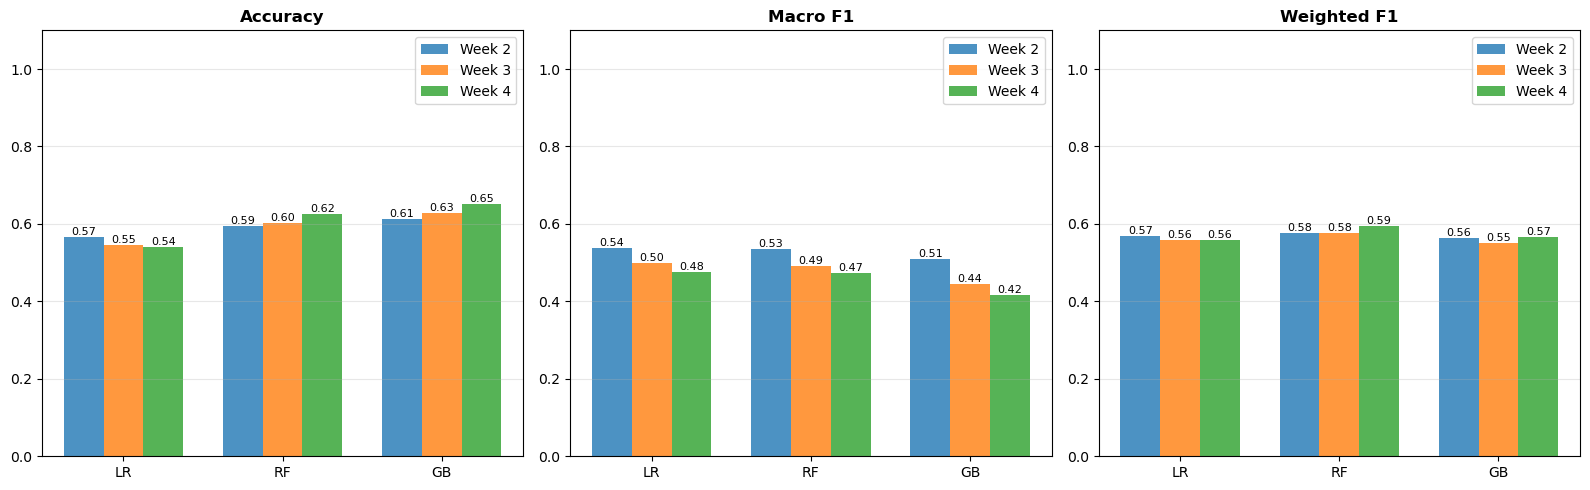

In [8]:
# Combine all results for comparison
all_results = {
    'Week 2': results_week2,
    'Week 3': results_week3,
    'Week 4': results_week4
}

# Plot multi-week comparison
comparison_df = plot_multi_week_comparison(all_results, weeks=['Week 2', 'Week 3', 'Week 4'])

In [9]:
# Per-class F1 scores analysis
print('\n' + '='*80)
print('PER-CLASS F1 SCORES ACROSS WEEKS')
print('='*80)

models = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
model_display = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

for week in ['Week 2', 'Week 3', 'Week 4']:
    print(f'\n{week}:')
    for model_key, model_name in zip(models, model_display):
        print(f"  {model_name}:")
        f1_scores = all_results[week][model_key]['f1_per_class']
        print(f"    Class 0 (Inactive):  F1 = {f1_scores[0]:.4f}")
        print(f"    Class 1 (Low 1-3):   F1 = {f1_scores[1]:.4f}")
        print(f"    Class 2 (High 4+):   F1 = {f1_scores[2]:.4f}")


PER-CLASS F1 SCORES ACROSS WEEKS

Week 2:
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6715
    Class 1 (Low 1-3):   F1 = 0.3403
    Class 2 (High 4+):   F1 = 0.6043
  Random Forest:
    Class 0 (Inactive):  F1 = 0.7179
    Class 1 (Low 1-3):   F1 = 0.2789
    Class 2 (High 4+):   F1 = 0.6073
  Gradient Boosting:
    Class 0 (Inactive):  F1 = 0.7368
    Class 1 (Low 1-3):   F1 = 0.1746
    Class 2 (High 4+):   F1 = 0.6180

Week 3:
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6732
    Class 1 (Low 1-3):   F1 = 0.2972
    Class 2 (High 4+):   F1 = 0.5248
  Random Forest:
    Class 0 (Inactive):  F1 = 0.7435
    Class 1 (Low 1-3):   F1 = 0.2090
    Class 2 (High 4+):   F1 = 0.5194
  Gradient Boosting:
    Class 0 (Inactive):  F1 = 0.7623
    Class 1 (Low 1-3):   F1 = 0.0451
    Class 2 (High 4+):   F1 = 0.5242

Week 4:
  Logistic Regression:
    Class 0 (Inactive):  F1 = 0.6771
    Class 1 (Low 1-3):   F1 = 0.2839
    Class 2 (High 4+):   F1 = 0.4674
  Random Forest:


## Save Models

Save trained models for Weeks 3 and 4 (Week 2 already saved in `5-model_second_week.ipynb`).

In [10]:
# Save Week 3 models
metadata_week3 = save_models(
    results_week3,
    scaler=data_week3['scaler'],
    feature_cols=list(X.columns),
    week_label="Week 3"
)

# Save Week 4 models
metadata_week4 = save_models(
    results_week4,
    scaler=data_week4['scaler'],
    feature_cols=list(X.columns),
    week_label="Week 4"
)

print("\n✓ All models saved successfully!")


SAVING MODELS - Week 3
✓ LogisticRegression saved: ../data/ale_simplicistic_model/relative/model_ready/logisticregression_week3_20260128_121228.pkl
✓ RandomForest saved: ../data/ale_simplicistic_model/relative/model_ready/randomforest_week3_20260128_121228.pkl
✓ GradientBoosting saved: ../data/ale_simplicistic_model/relative/model_ready/gradientboosting_week3_20260128_121228.pkl
✓ Scaler saved: ../data/ale_simplicistic_model/relative/model_ready/scaler_week3_20260128_121228.pkl
✓ Metadata saved: ../data/ale_simplicistic_model/relative/model_ready/metadata_week3_20260128_121228.pkl

SAVING MODELS - Week 4
✓ LogisticRegression saved: ../data/ale_simplicistic_model/relative/model_ready/logisticregression_week4_20260128_121228.pkl
✓ RandomForest saved: ../data/ale_simplicistic_model/relative/model_ready/randomforest_week3_20260128_121228.pkl
✓ GradientBoosting saved: ../data/ale_simplicistic_model/relative/model_ready/gradientboosting_week3_20260128_121228.pkl
✓ Scaler saved: ../data/ale_